# Week 6 - Bivariate Analysis, part 2

# 1. Lesson: no lesson this week

# 2. Weekly graph question

Suppose you wanted to show the nitrate and phosphate level in a water sample.  What are the advantages and disadvantages of showing this as an area plot, as opposed to two separate line graphs?  How would you adjust the graphs shown to improve the presentation?

In [3]:
!pip install openpyxl

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [openpyxl]1/2 [openpyxl]

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip


In [1]:
import numpy as np
import seaborn as sns
import pandas as pd

Text(0, 0.5, 'Nitrate level (% of eutrophic value)')

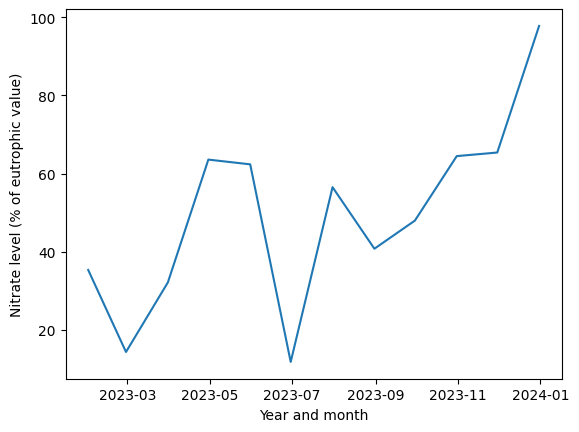

In [3]:
numdates = 12
np.random.seed(0)
time_series = 100 * (np.random.normal(size = numdates) / 5 + np.arange(numdates) / 16)
datearray = pd.date_range(start='2023/01/01', end='2024/01/01', freq='ME')
ax = sns.lineplot(x = datearray, y = time_series)
ax.set_xlabel("Year and month")
ax.set_ylabel("Nitrate level (% of eutrophic value)")

Text(0, 0.5, 'Phosphate level (% of eutrophic value)')

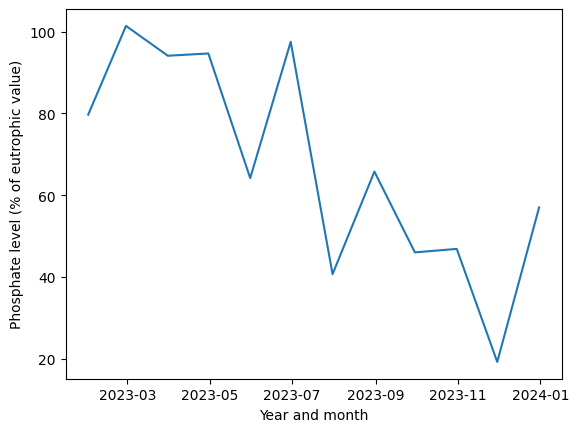

In [4]:
np.random.seed(1)
time_series_2 =  100 * (1 - (np.random.normal(size = numdates) / 8 + np.arange(numdates) / 16))
datearray = pd.date_range(start='2023/01/01', end='2024/01/01', freq='ME')
ax = sns.lineplot(x = datearray, y = time_series_2)
ax.set_xlabel("Year and month")
ax.set_ylabel("Phosphate level (% of eutrophic value)")

<Axes: >

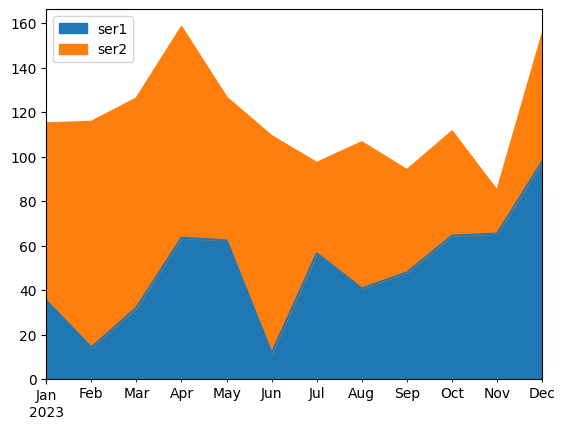

In [5]:
df = pd.DataFrame({'ser1': time_series, 'ser2': time_series_2}, index = datearray)
df.plot.area()

# 3. Working on your datasets

This week, you will do the same types of exercises as last week, but you should use your chosen datasets that someone in your class found last semester. (They likely will not be the particular datasets that you found yourself.)

### Here are some types of analysis you can do:

- Find correlations between pairs of variables.

- Draw scatterplots, especially when the correlation is large.

- Draw pairplots.

- Draw line graphs and/or area graphs when there is date or time data together with numerical data.

### Conclusions:

- Explain what conclusions you would draw from this analysis: are the data what you expect?  Are the data likely to be usable?  If the data are not useable, find some new data!

- Do you see any outliers?  (Data points that are far from the rest of the data).

- Are any data items highly correlated with each other, suggesting that they are redundant?

- For the line plots, do you see a trend or pattern over time?  Does this suggest that the data are changing over time (drifting) in such a way as to invalidate comparisons?

- Can you think of any confounding variables?  (Third variables that could explain any correlations between other variables.  These third variables may or may not be reported in the dataset.)

In [2]:
!pip install pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 17.6 MB/s  0:00:00m0:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 40.1 MB/s  0:00:006m0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [pandas]2m1/2 [pandas]

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip


In [9]:
!pip install matplotlib


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip


In [10]:
!pip install seaborn


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip


In [4]:
import pandas as pd

df = pd.read_csv("/workspaces/DX699_02/data/Retail_and_ECommerce/us_ecommerce/US  E-commerce records 2020.csv", encoding="latin1")

In [5]:
#corr
corr = df.corr(numeric_only=True)
print(corr)

               Row ID  Postal Code     Sales  Quantity  Discount    Profit
Row ID       1.000000     0.010569 -0.001343 -0.008991  0.021773  0.017903
Postal Code  0.010569     1.000000 -0.019208  0.034058  0.039077 -0.009939
Sales       -0.001343    -0.019208  1.000000  0.191127 -0.033516  0.532312
Quantity    -0.008991     0.034058  0.191127  1.000000  0.019184  0.053766
Discount     0.021773     0.039077 -0.033516  0.019184  1.000000 -0.218343
Profit       0.017903    -0.009939  0.532312  0.053766 -0.218343  1.000000


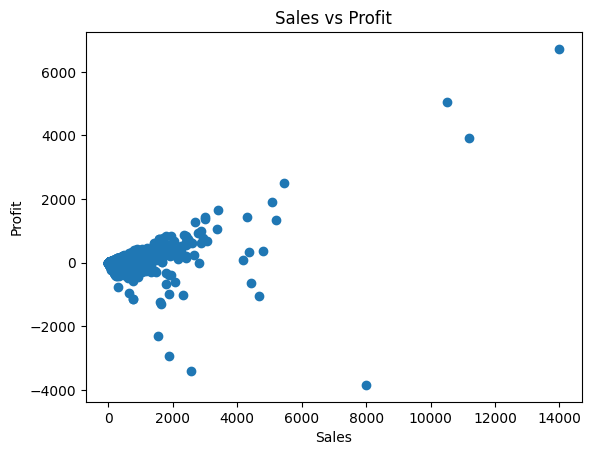

In [8]:
#scatter plots
import matplotlib.pyplot as plt

plt.scatter(df["Sales"], df["Profit"])
plt.xlabel("Sales")
plt.ylabel("Profit")
plt.title("Sales vs Profit")
plt.show()


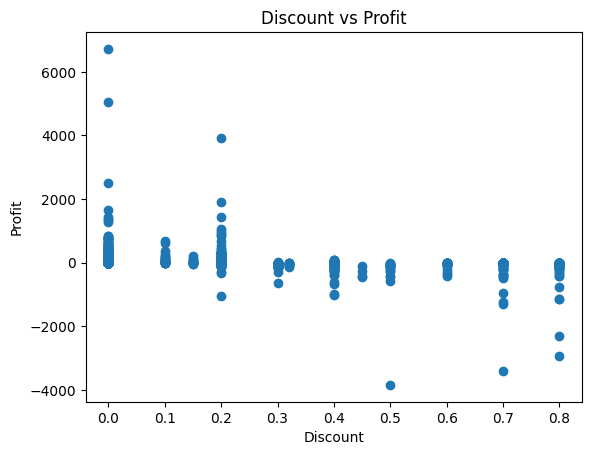

In [9]:
plt.scatter(df["Discount"], df["Profit"])
plt.xlabel("Discount")
plt.ylabel("Profit")
plt.title("Discount vs Profit")
plt.show()

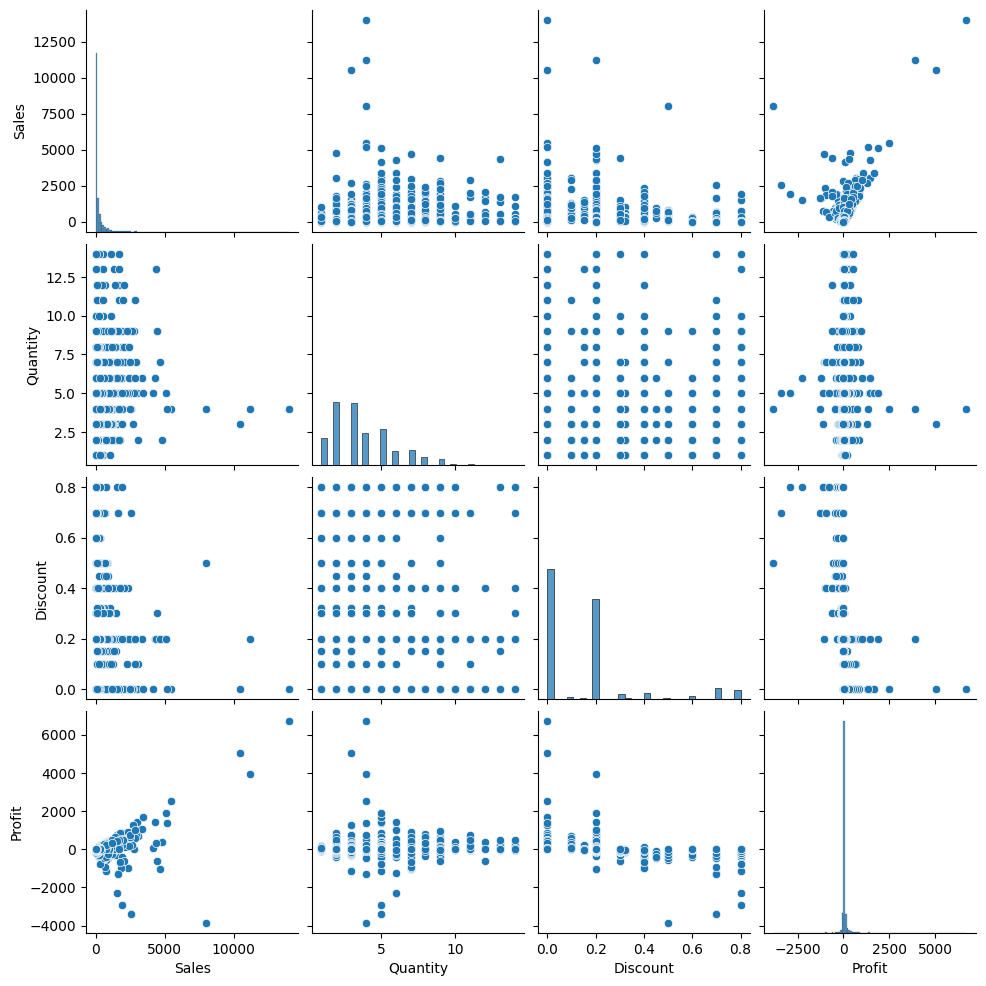

In [11]:
#pairplot
import seaborn as sns

sns.pairplot(df[["Sales","Quantity","Discount","Profit"]])
plt.show()

/tmp/ipykernel_10519/1156629199.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["Order Date"] = pd.to_datetime(df["Order Date"])


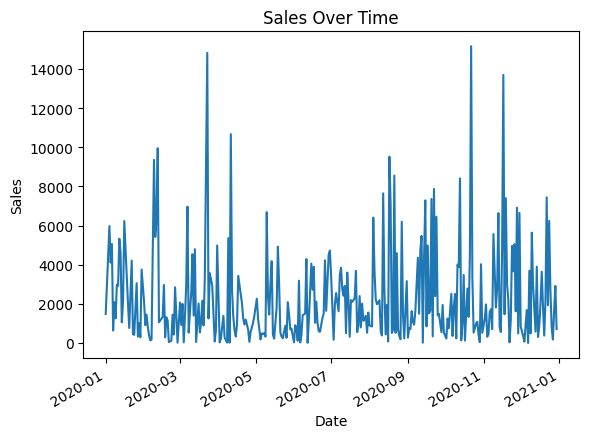

In [12]:
#line graph
df["Order Date"] = pd.to_datetime(df["Order Date"])

sales_time = df.groupby("Order Date")["Sales"].sum()

sales_time.plot()
plt.title("Sales Over Time")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.show()

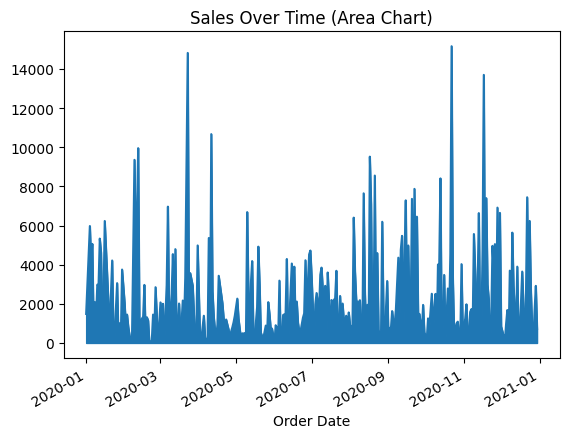

In [13]:
#area graph
sales_time.plot.area()
plt.title("Sales Over Time (Area Chart)")
plt.show()

# 4. Storytelling With Data plot

Reproduce any graph of your choice in p. 86-98 of the Storytelling With Data book as best you can.  (The second half of chapter three).  You do not have to get the exact data values right, just the overall look and feel.

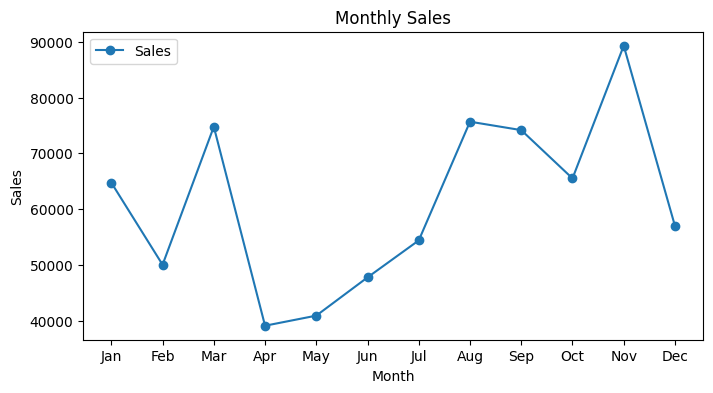

In [14]:
import pandas as pd
import matplotlib.pyplot as plt

# convert date column
df["Order Date"] = pd.to_datetime(df["Order Date"])

# create month column
df["Month"] = df["Order Date"].dt.month_name().str[:3]

# order months correctly
month_order = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
df["Month"] = pd.Categorical(df["Month"], categories=month_order, ordered=True)

# group by month
monthly_sales = df.groupby("Month")["Sales"].sum()

# plot
plt.figure(figsize=(8,4))
plt.plot(monthly_sales.index, monthly_sales.values, marker="o", label="Sales")

plt.title("Monthly Sales")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.legend()

plt.show()

ANSWER:
1. What conclusions can we draw? Are the data usable?

The data mostly look reasonable and usable. The scatterplots and pairplots show logical relationships between some variables. For example, Sales and Profit have a moderate positive correlation (~0.53), which makes sense because higher sales usually lead to higher profit.

Discount has a negative correlation with Profit (~-0.22), which is also expected because larger discounts reduce profit margins. Overall, the relationships in the data appear realistic, so the dataset seems usable for analysis.

2. Do you see any outliers?

Yes, there appear to be some outliers. In the Sales vs Profit scatterplot, there are several points with very high sales values and very large positive or negative profits that are far from the rest of the data. There are also a few points with very negative profits (large losses). These could represent unusually large transactions or special cases.

3. Are any variables highly correlated?

The strongest correlation is between Sales and Profit (0.53), which suggests a moderate relationship but not a redundant one.

Other variables such as Quantity and Sales (~0.19) or Discount and Profit (~-0.22) have weaker relationships. None of the variables appear to be extremely highly correlated (close to ±1), so they likely are not redundant.

4. Do the line plots show a trend over time?

The line plot of sales over time appears very noisy, with many spikes and drops. There does not seem to be a clear upward or downward trend across the year. Instead, sales fluctuate frequently, which likely reflects normal variation in daily orders rather than a long-term trend.

This suggests the data are not obviously drifting over time, so comparisons across the year should still be reasonable.

5. Possible confounding variables

There could be several confounding variables that affect the relationships observed:

Product category or product type (some items may naturally have higher profit margins)

Region or location (different areas may have different sales patterns)

Seasonality (certain months may have higher demand)

Customer type (business vs individual buyers)

These variables might explain some of the variation in sales, profit, or discount that we see in the plots.

conclusion:
The dataset appears reasonable and usable. The relationships between sales, profit, and discount behave in ways that are generally expected, though there are some outliers and variability that could be explored further.

<hr>

In [6]:
import pandas as pd

df = pd.read_excel("/workspaces/DX699_02/data/online_retail/Online Retail.xlsx")

In [7]:
#corr
df["TotalPrice"] = df["Quantity"] * df["UnitPrice"]

corr = df[["Quantity","UnitPrice","TotalPrice"]].corr()
print(corr)

            Quantity  UnitPrice  TotalPrice
Quantity    1.000000  -0.001235    0.886681
UnitPrice  -0.001235   1.000000   -0.162029
TotalPrice  0.886681  -0.162029    1.000000


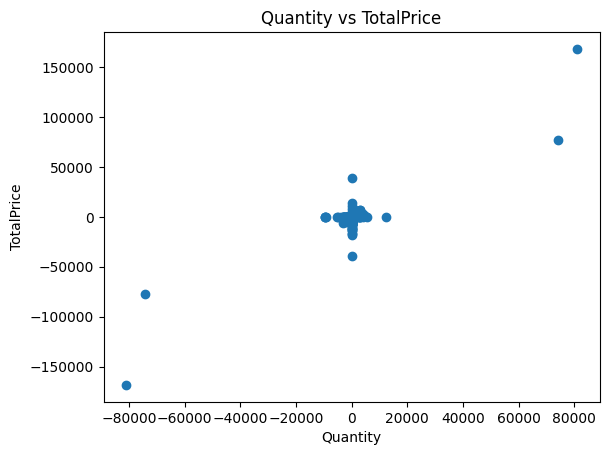

In [14]:
#scatter
import matplotlib.pyplot as plt
import seaborn as sns
plt.scatter(df["Quantity"], df["TotalPrice"])
plt.xlabel("Quantity")
plt.ylabel("TotalPrice")
plt.title("Quantity vs TotalPrice")
plt.show()

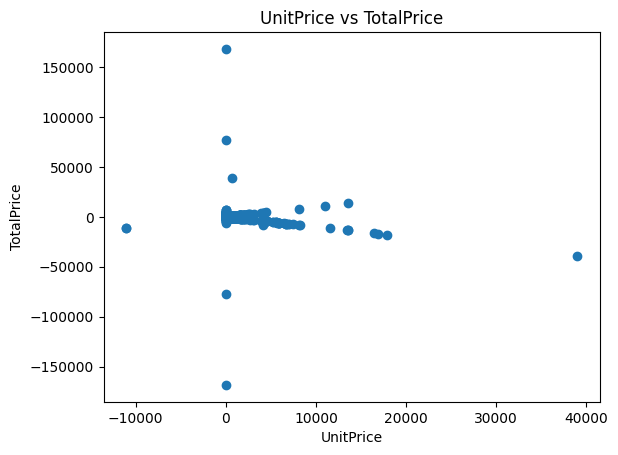

In [15]:
plt.scatter(df["UnitPrice"], df["TotalPrice"])
plt.xlabel("UnitPrice")
plt.ylabel("TotalPrice")
plt.title("UnitPrice vs TotalPrice")
plt.show()

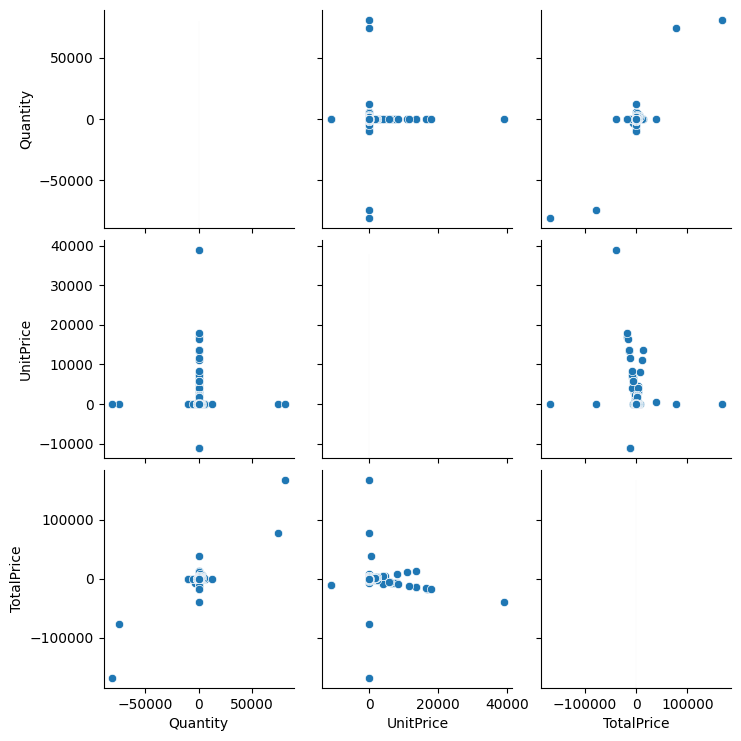

In [16]:
#paitplot
sns.pairplot(df[["Quantity","UnitPrice","TotalPrice"]])
plt.show()

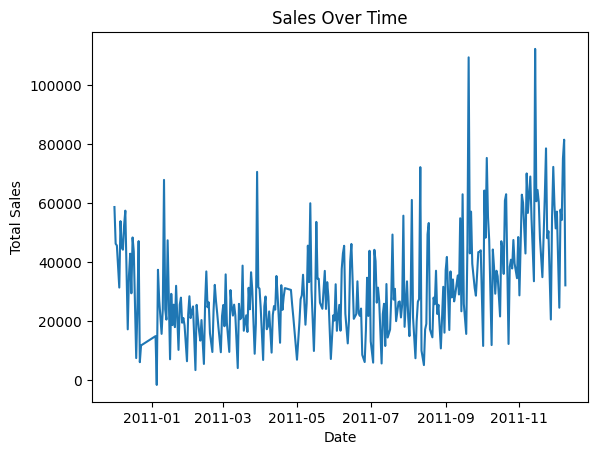

In [17]:
#linegraph
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

daily_sales = df.groupby(df["InvoiceDate"].dt.date)["TotalPrice"].sum()

daily_sales.plot()
plt.title("Sales Over Time")
plt.xlabel("Date")
plt.ylabel("Total Sales")
plt.show()

ANSWER:

Conclusions

Are the data what you expect? Are the data usable?
The data mostly look reasonable and usable. The strong correlation between Quantity and TotalPrice (0.8867) is expected because total price depends on how many items are purchased. The relationships between the other variables are weaker, which is also realistic for retail data.

Do you see any outliers?
Yes, there are some outliers in the scatterplots. A few data points have extremely large values for Quantity, UnitPrice, or TotalPrice compared to the rest of the data. These could represent bulk purchases, data entry errors, or unusual transactions.

Are any variables highly correlated or redundant?
Yes. Quantity and TotalPrice are highly correlated, which makes sense since TotalPrice is calculated using Quantity. Because of this, these two variables may contain redundant information for some analyses.

Do the line plots show a trend over time?
The line graph shows that sales fluctuate over time with many spikes and drops. Toward the later part of the year, there appear to be higher sales values, which could suggest seasonal demand such as holiday shopping. However, the pattern is noisy and does not show a perfectly consistent trend.

Possible confounding variables
There may be other variables influencing the relationships in the data, such as:

Product type or category

Country or region of the customer

Seasonal events or holidays

Customer behavior or bulk purchasing

These factors could help explain why some purchases have very high quantities or prices.

conclusion:
The dataset appears usable, but it contains some outliers and variability that may need to be investigated further before building models or making strong conclusions.